# MindLens-AI - Complete Analysis Pipeline

## Overview

This notebook contains all analysis stages for the Reddit Mental Health classification project.

| Section | Description |
|---------|-------------|
| 1 | Exploratory Data Analysis |
| 2 | Model Training |
| 3 | Explainability (RQ1) |
| 4 | Bias Testing (RQ2) |
| 5 | Robustness Testing (RQ3) |





## Section 1: Exploratory Data Analysis

*Dataset exploration, class balance, text analysis*




In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from src.preprocessing import load_rmhd_dataset, preprocess_pipeline, save_processed
from src.features import build_tfidf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print("Setup done.")

Setup done.


### 1. Load and Preprocess

In [39]:
raw_df = load_rmhd_dataset(
    data_dir="../data/raw/Original Reddit Data/raw data",
    sample_per_class=10_000,
    random_state=42,
)
print(f"Raw dataset: {raw_df.shape[0]} rows, {raw_df.shape[1]} cols")
print(raw_df["label"].value_counts())
print("\nSubreddit breakdown:")
print(raw_df["subreddit"].value_counts())

df = preprocess_pipeline(raw_df, remove_stopwords=False)
print(f"\nAfter cleaning: {df.shape[0]} rows")
df.head()

RMHD loaded: 20000 rows  |  label distribution:
{1: 10000, 0: 10000}
Raw dataset: 20000 rows, 3 cols
label
1    10000
0    10000
Name: count, dtype: int64

Subreddit breakdown:
subreddit
depression      5661
SuicideWatch    4339
mentalhealth    4107
Anxiety         3803
lonely          2090
Name: count, dtype: int64

After cleaning: 19956 rows


,text,label,subreddit,word_count,char_count,avg_word_length,word_density,unique_word_ratio
0,i ve decided to sleep until i die every method...,1,SuicideWatch,32,165,5.156250,0.193939,0.875000
1,what to do when you don t feel any happiness o...,1,depression,432,1988,4.601852,0.217304,0.418981
2,i don t know what to do anymore so i m not gon...,1,SuicideWatch,182,855,4.697802,0.212865,0.560440
3,each day is getting worse at the moment i neve...,1,depression,149,713,4.785235,0.208976,0.590604
4,update i ve told in my other post that i told ...,1,SuicideWatch,311,1468,4.720257,0.211853,0.495177


### 2. Quick Overview

In [3]:
print("Shape:", df.shape)
print("\n--- Info ---")
df.info()
print("\n--- Describe ---")
df.describe()

Shape: (19956, 8)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19956 entries, 0 to 19955
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text               19956 non-null  object 
 1   label              19956 non-null  int64  
 2   subreddit          19956 non-null  object 
 3   word_count         19956 non-null  int64  
 4   char_count         19956 non-null  int64  
 5   avg_word_length    19956 non-null  float64
 6   word_density       19956 non-null  float64
 7   unique_word_ratio  19956 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.2+ MB

--- Describe ---


,label,word_count,char_count,avg_word_length,word_density,unique_word_ratio
count,19956.000000,19956.000000,19956.000000,19956.000000,19956.000000,19956.000000
mean,0.500301,167.605282,819.489076,4.988292,0.204265,0.681791
std,0.500012,214.029596,1054.098413,5.741657,0.018675,0.168826
min,0.000000,1.000000,2.000000,2.000000,0.001240,0.011765
25%,0.000000,45.000000,217.000000,4.666667,0.196106,0.558421
50%,1.000000,108.000000,525.000000,4.869758,0.205349,0.659091
75%,1.000000,213.000000,1036.000000,5.099291,0.214286,0.791667
max,1.000000,6468.000000,31001.000000,806.500000,0.500000,1.000000


### 2b. Data Quality Assessment

In [4]:
# Missing values
print("Missing values:\n", raw_df[["text", "label"]].isnull().sum())

# Duplicates
n_dupes = raw_df.duplicated(subset=["text"]).sum()
print(f"\nDuplicates in raw data: {n_dupes} (removed by pipeline)")

# Subreddit composition
print("\nSubreddit composition (before cleaning):")
for sub in raw_df["subreddit"].unique():
    n = (raw_df["subreddit"] == sub).sum()
    lab = 1 if sub in {"depression", "SuicideWatch"} else 0
    print(f"  {sub}: {n} posts -> label {lab}")

# Outliers (word count, IQR)
Q1, Q3 = df["word_count"].quantile(0.25), df["word_count"].quantile(0.75)
upper = Q3 + 1.5 * (Q3 - Q1)
n_outliers = (df["word_count"] > upper).sum()
print(f"\nWord-count outliers (>{upper:.0f}): {n_outliers} ({n_outliers/len(df)*100:.1f}%) — long posts, retained")

Missing values:
 text     0
label    0
dtype: int64

Duplicates in raw data: 29 (removed by pipeline)

Subreddit composition (before cleaning):
  SuicideWatch: 4339 posts -> label 1
  depression: 5661 posts -> label 1
  mentalhealth: 4107 posts -> label 0
  Anxiety: 3803 posts -> label 0
  lonely: 2090 posts -> label 0

Word-count outliers (>465): 1285 (6.4%) — long posts, retained


### 3. Class Distribution

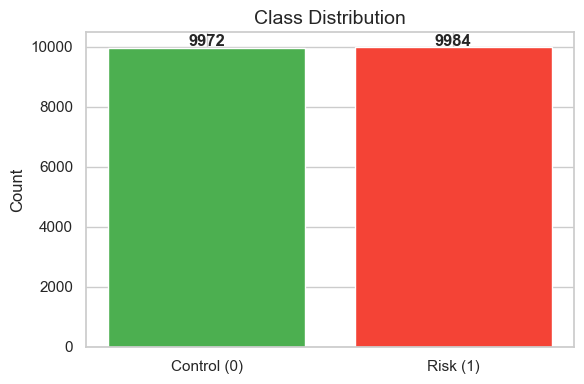

Class balance -- Control: 9972 (50.0%)  |  Risk: 9984 (50.0%)


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["label"].value_counts().sort_index()
bars = ax.bar(["Control (0)", "Risk (1)"], counts.values, color=["#4CAF50", "#F44336"])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(val), ha="center", fontweight="bold")
ax.set_title("Class Distribution", fontsize=14)
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

ratio_0 = counts[0] / len(df) * 100
ratio_1 = counts[1] / len(df) * 100
print(f"Class balance -- Control: {counts[0]} ({ratio_0:.1f}%)  |  Risk: {counts[1]} ({ratio_1:.1f}%)")

### 3b. Post Distribution by Subreddit

C:\Users\Kartik\AppData\Local\Temp\ipykernel_23248\502997354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="subreddit", order=df["subreddit"].value_counts().index,


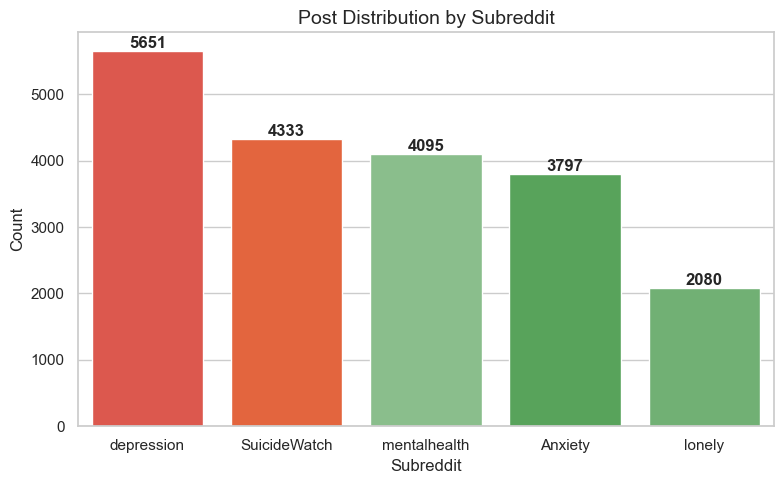

Risk (1) subreddits:   depression, SuicideWatch
Control (0) subreddits: Anxiety, lonely, mentalhealth


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="subreddit", order=df["subreddit"].value_counts().index,
              palette={"depression": "#F44336", "SuicideWatch": "#FF5722",
                       "Anxiety": "#4CAF50", "lonely": "#66BB6A", "mentalhealth": "#81C784"},
              ax=ax)
plt.title("Post Distribution by Subreddit", fontsize=14)
ax.set_xlabel("Subreddit")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

print("Risk (1) subreddits:   depression, SuicideWatch")
print("Control (0) subreddits: Anxiety, lonely, mentalhealth")

### 4. Text Length Analysis

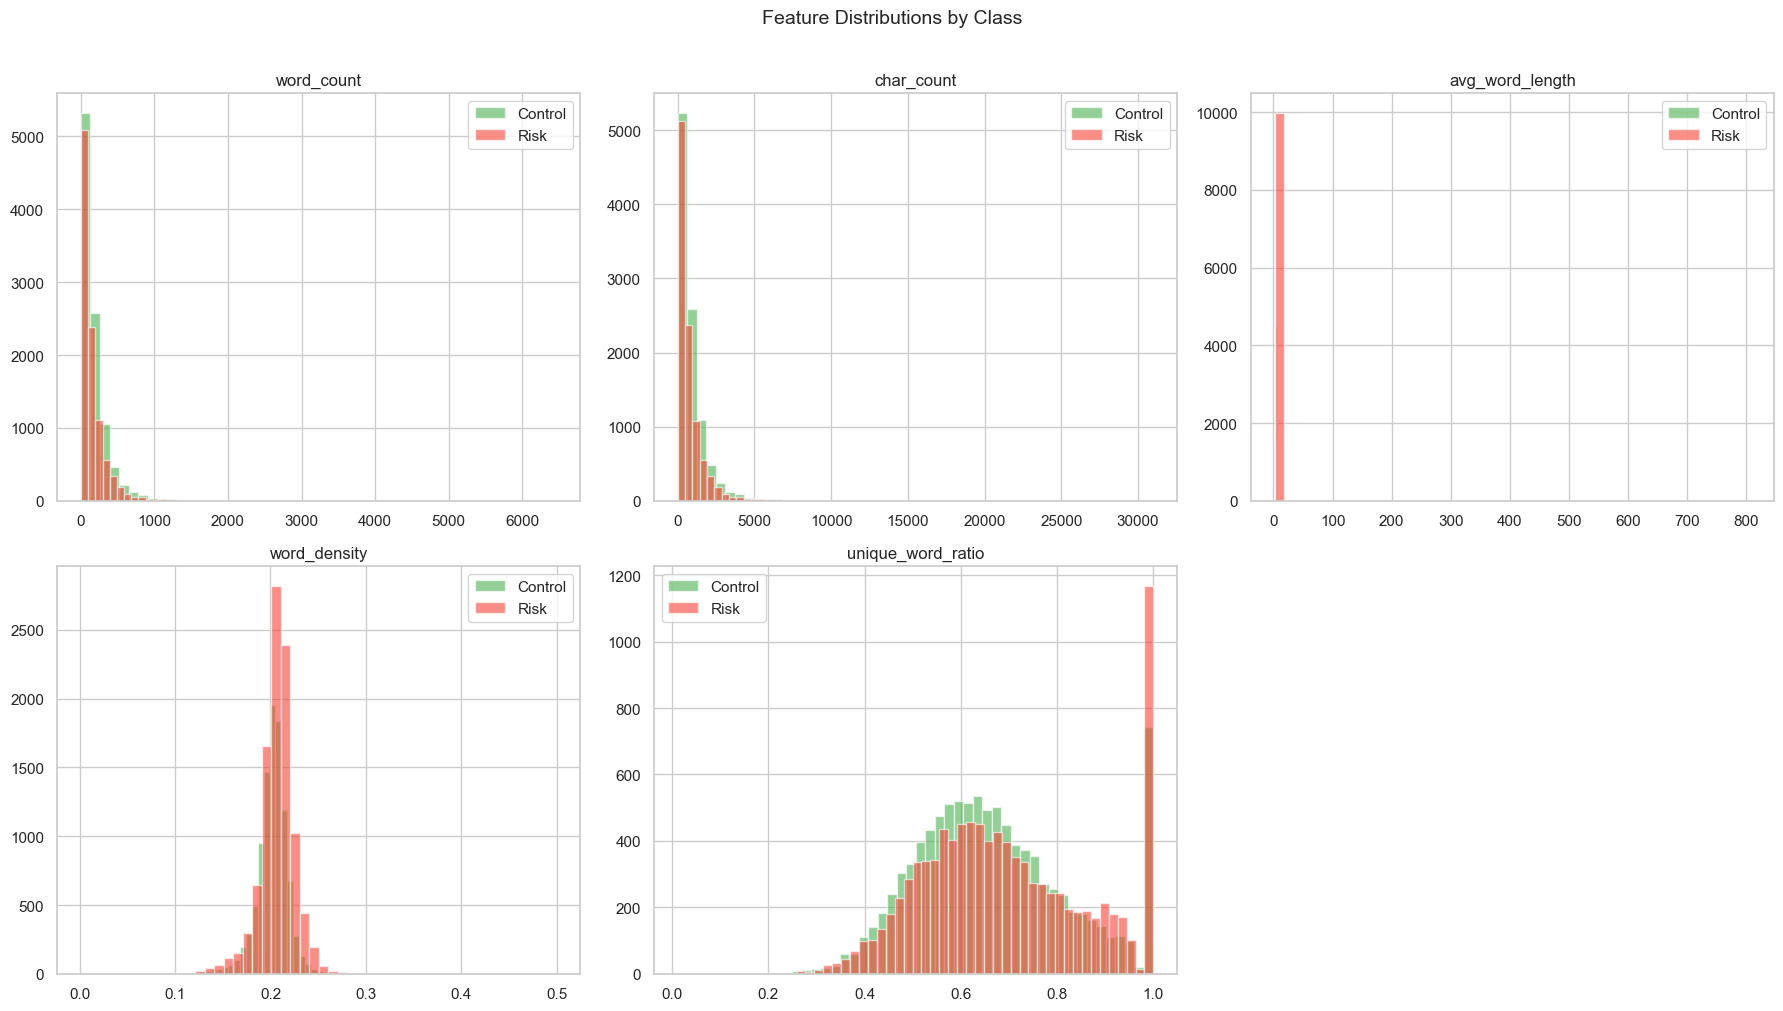

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features = ["word_count", "char_count", "avg_word_length", "word_density", "unique_word_ratio"]
labels_map = {0: "Control", 1: "Risk"}
colors = {0: "#4CAF50", 1: "#F44336"}

for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    for lab in [0, 1]:
        subset = df[df["label"] == lab][feat]
        ax.hist(subset, bins=50, alpha=0.6, label=labels_map[lab], color=colors[lab])
    ax.set_title(feat, fontsize=12)
    ax.legend()

# Remove empty subplot
axes[1][2].set_visible(False)
plt.suptitle("Feature Distributions by Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6. Top TF-IDF Terms per Class

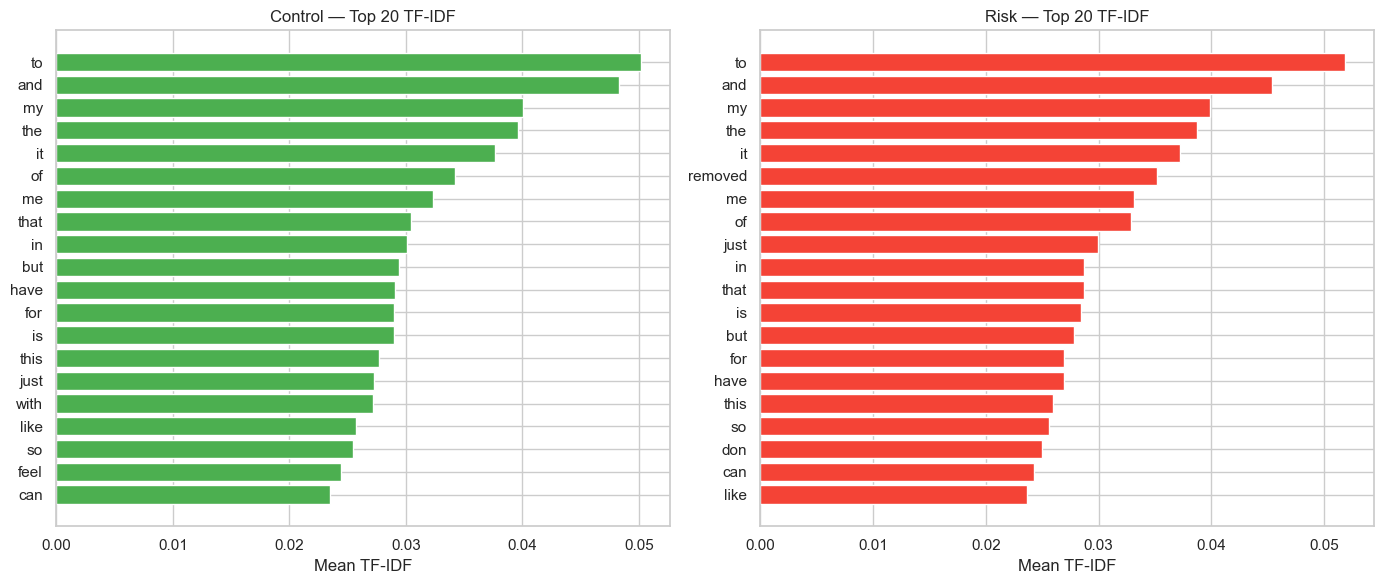

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (lab, title, color) in enumerate([(0, "Control — Top 20 TF-IDF", "#4CAF50"),
                                            (1, "Risk — Top 20 TF-IDF", "#F44336")]):
    subset_texts = df[df["label"] == lab]["text"]
    vec, X = build_tfidf(subset_texts, max_features=5000)
    mean_tfidf = X.mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-20:]
    words = np.array(vec.get_feature_names_out())[top_idx]
    scores = mean_tfidf[top_idx]

    axes[idx].barh(words, scores, color=color)
    axes[idx].set_title(title, fontsize=12)
    axes[idx].set_xlabel("Mean TF-IDF")

plt.tight_layout()
plt.show()

### 7. Feature Correlations

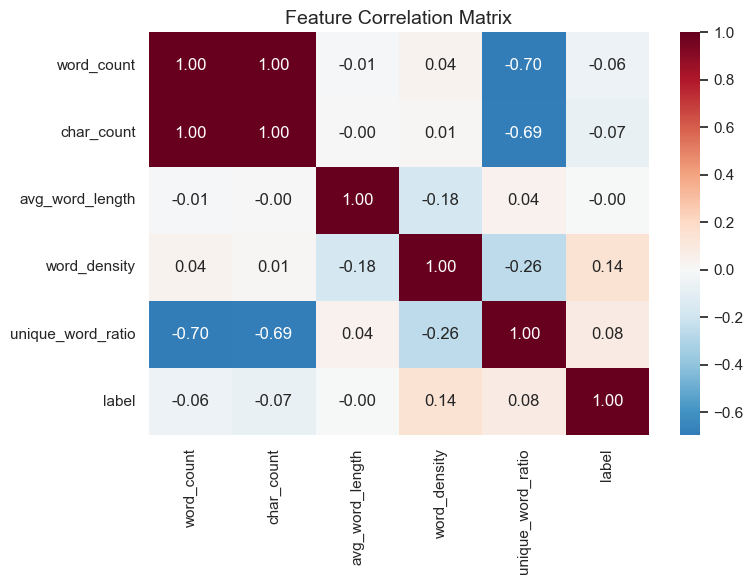

In [10]:
numeric_cols = ["word_count", "char_count", "avg_word_length", "word_density", "unique_word_ratio", "label"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Summary Statistics by Class

In [11]:
summary = df.groupby("label")[["word_count", "char_count", "avg_word_length",
                               "word_density", "unique_word_ratio"]].agg(["mean", "median", "std"])
summary.columns = ["_".join(c) for c in summary.columns]
summary

,word_count_mean,word_count_median,word_count_std,char_count_mean,char_count_median,char_count_std,avg_word_length_mean,avg_word_length_median,avg_word_length_std,word_density_mean,word_density_median,word_density_std,unique_word_ratio_mean,unique_word_ratio_median,unique_word_ratio_std
label,,,,,,,,,,,,,,,
0,180.328720,120.0,221.381909,890.746791,587.0,1098.297221,5.002689,4.925061,0.526449,0.201594,0.203043,0.017178,0.667728,0.647356,0.161624
1,154.897135,95.0,205.651653,748.317007,459.0,1003.034278,4.973911,4.808895,8.100599,0.206932,0.207948,0.019701,0.695836,0.670588,0.174607


### 8. Save Processed Data

In [12]:
save_processed(df, "../data/processed/primary_clean.csv")
print("Columns saved:", list(df.columns))
print("EDA done.")

Saved 19956 rows -> ../data/processed/primary_clean.csv
Columns saved: ['text', 'label', 'subreddit', 'word_count', 'char_count', 'avg_word_length', 'word_density', 'unique_word_ratio']
EDA done.


### 9. Baseline Model (Word Count Only)

A quick sanity check: can word count alone predict mental-health risk? This establishes a trivial baseline that the full TF-IDF model (Notebook 02) must beat.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df[['word_count']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.55      0.38      0.45      1995
           1       0.53      0.69      0.60      1997

    accuracy                           0.53      3992
   macro avg       0.54      0.53      0.52      3992
weighted avg       0.54      0.53      0.52      3992



---
## Section 2: Model Training

*TF-IDF + Logistic Regression, cross-validation, DistilBERT*

---


In [15]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

from src.features import build_tfidf
from src.model import train_baseline, save_model, get_device
from src.evaluation import evaluate_single, cross_validate_model, error_analysis

sns.set_theme(style="whitegrid", palette="muted")

device = get_device()
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("No GPU found -- LR runs on CPU anyway, DistilBERT will be slow.")

print("Ready.")

Using device: cuda
GPU detected: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA version: 12.4
Ready.


### 1. Load Data and Build TF-IDF Features

In [16]:
df = pd.read_csv("../data/processed/primary_clean.csv")
print(f"Loaded {len(df)} samples")

all_texts = df["text"].values
all_labels = df["label"].values

vectorizer, tfidf_matrix = build_tfidf(all_texts, max_features=5000)
vocab = vectorizer.get_feature_names_out()
print(f"TF-IDF shape: {tfidf_matrix.shape}")

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    tfidf_matrix, all_labels, np.arange(len(all_labels)),
    test_size=0.2, stratify=all_labels, random_state=42,
)
test_texts = all_texts[idx_test]
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Loaded 19956 samples
TF-IDF shape: (19956, 5000)
Train: 15964  |  Test: 3992


### 2. Cross-Validation (5-Fold Stratified)

In [17]:
cv_table = cross_validate_model(
    LogisticRegression,
    tfidf_matrix, all_labels,
    n_splits=5,
    model_kwargs={"class_weight": "balanced", "max_iter": 1000, "solver": "lbfgs", "random_state": 42},
)
cv_table

  Fold 1: F1=0.7763  ROC-AUC=0.8554981595199818
  Fold 2: F1=0.7743  ROC-AUC=0.8535903152622615
  Fold 3: F1=0.7851  ROC-AUC=0.8641772839801327
  Fold 4: F1=0.7795  ROC-AUC=0.8590080456693063
  Fold 5: F1=0.7836  ROC-AUC=0.8621162123746241


,fold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,0.773547,0.767237,0.785679,0.776348,0.855498,0.836367
1,2,0.771235,0.764648,0.784176,0.774289,0.85359,0.827248
2,3,0.784515,0.783541,0.78668,0.785107,0.864177,0.848627
3,4,0.77775,0.773939,0.785178,0.779518,0.859008,0.8418
4,5,0.781508,0.776303,0.791082,0.783623,0.862116,0.849372
5,mean+/-std,0.7777 +/- 0.0055,0.7731 +/- 0.0075,0.7866 +/- 0.0027,0.7798 +/- 0.0046,0.8589 +/- 0.0044,0.8407 +/- 0.0092


### 3. Train Final Model on Train Set

In [18]:
model = train_baseline(X_train, y_train, max_iter=1000)

results = evaluate_single(model, X_test, y_test)
print("--- Test Set Performance ---")
print(results["classification_report"])
print(f"ROC-AUC: {results.get('roc_auc', 'N/A'):.4f}")
print(f"PR-AUC:  {results.get('pr_auc', 'N/A'):.4f}")

--- Test Set Performance ---
              precision    recall  f1-score   support

           0       0.78      0.76      0.77      1995
           1       0.76      0.78      0.77      1997

    accuracy                           0.77      3992
   macro avg       0.77      0.77      0.77      3992
weighted avg       0.77      0.77      0.77      3992

ROC-AUC: 0.8515
PR-AUC:  0.8323


### 4. Confusion Matrix, ROC Curve & PR Curve

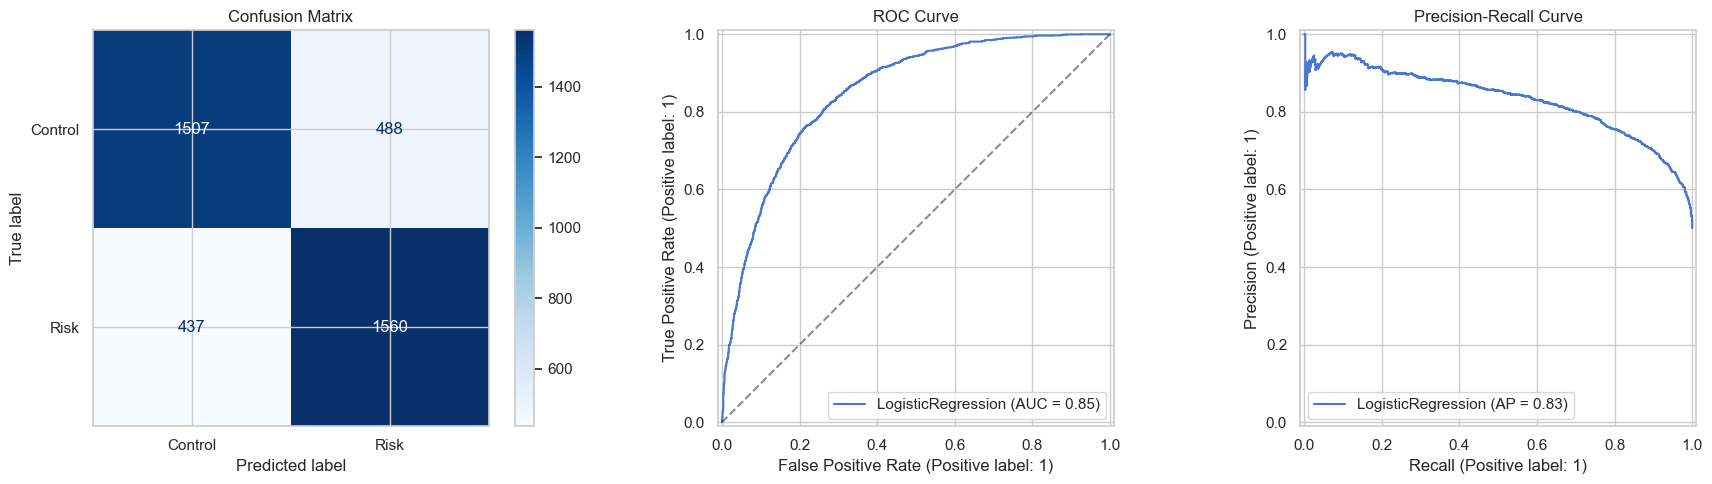

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = results["confusion_matrix"]
ConfusionMatrixDisplay(cm, display_labels=["Control", "Risk"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)

PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[2])
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

### 5. Error Analysis (Top 20 FP & FN)

In [20]:
fp_df, fn_df = error_analysis(model, X_test, y_test, test_texts, n=20)

print("--- Top 20 False Positives (predicted Risk, actually Control) ---")
for i, row in fp_df.iterrows():
    print(f"\n  [FP-{i+1}] confidence={row['confidence']:.3f}")
    print(f"    {row['text'][:200]}...")

print("\n\n--- Top 20 False Negatives (predicted Control, actually Risk) ---")
for i, row in fn_df.iterrows():
    print(f"\n  [FN-{i+1}] confidence={row['confidence']:.3f}")
    print(f"    {row['text'][:200]}...")

--- Top 20 False Positives (predicted Risk, actually Control) ---

  [FP-1] confidence=0.987
    depressed for over years suicidal for i dont see any reason for me to keep living tried to do some things to make myself better i fucking tried ok keeping on doing same things hoping they would work i...

  [FP-2] confidence=0.983
    i dont want to die but i don t want to live removed...

  [FP-3] confidence=0.977
    goodbye i plan to kill myself tonight i can no longer live every day feeling like this i care so much about everyone around me and nobody really cares about me i just feel useless and like i take up s...

  [FP-4] confidence=0.968
    im going to die be happy humanity no one cares if im dead or im alive...

  [FP-5] confidence=0.967
    im tired i just feel like a burden to everybody around me i dont have enough courage to kill myself it hurts it hurts so fucking much...

  [FP-6] confidence=0.967
    the only thing that stopped me from killing myself tonight is that i didn t

### 6. Save Model Artifacts

In [21]:
save_model(model, vectorizer, "../data/processed/model_artifacts.joblib")

import joblib
joblib.dump({
    "X_test": X_test, "y_test": y_test, "texts_test": test_texts,
    "X_train": X_train, "y_train": y_train,
    "feature_names": list(vocab),
}, "../data/processed/test_split.joblib")
print("Artifacts saved.")

Model saved -> ../data/processed/model_artifacts.joblib
Artifacts saved.


### 7. (Optional) DistilBERT Fine-tuning

Skip this cell if you don't have a GPU with at least 4 GB VRAM.

In [ ]:
# from src.model import train_distilbert

# train_raw = df.iloc[idx_train]["text"].values
# test_raw  = df.iloc[idx_test]["text"].values

# trainer, tokenizer = train_distilbert(
#     train_texts=train_raw,
#     train_labels=y_train,
#     val_texts=test_raw,
#     val_labels=y_test,
#     epochs=3,
#     batch_size=16,
#     output_dir="../data/processed/distilbert_model",
# )

# print("DistilBERT evaluation:", trainer.evaluate())
# print("Done.")


Using device: cuda


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.442600,0.455658,0.786323,0.797628
2,0.364000,0.471769,0.790080,0.798267
3,0.285100,0.508734,0.786573,0.791789


DistilBERT evaluation: {'eval_loss': 0.4556582272052765, 'eval_accuracy': 0.7863226452905812, 'eval_f1': 0.7976275207591934, 'eval_runtime': 4.9251, 'eval_samples_per_second': 810.544, 'eval_steps_per_second': 25.38, 'epoch': 3.0}
Done.


---
## Section 3: Explainability (RQ1)

*SHAP & LIME explanations*

---


In [23]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from src.model import load_model
from src.explainability import (
    explain_with_lime, explain_with_shap, shap_summary,
    interpretability_score, mental_health_vocabulary,
)

sns.set_theme(style="whitegrid")

model, vectorizer = load_model("../data/processed/model_artifacts.joblib")
split = joblib.load("../data/processed/test_split.joblib")
X_test = split["X_test"]
X_train = split["X_train"]
y_test = split["y_test"]
test_texts = split["texts_test"]
feature_names = split["feature_names"]

print(f"Loaded model and {len(test_texts)} test samples.")

Loaded model and 3992 test samples.


### 1. SHAP -- Global Feature Importance

SHAP values shape: (3992, 5000)

c:\Users\Kartik\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


c:\Users\Kartik\Documents\Kartik\EDU\Projects\MindLens-AI\src\explainability.py:69: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test, feature_names=feature_names,


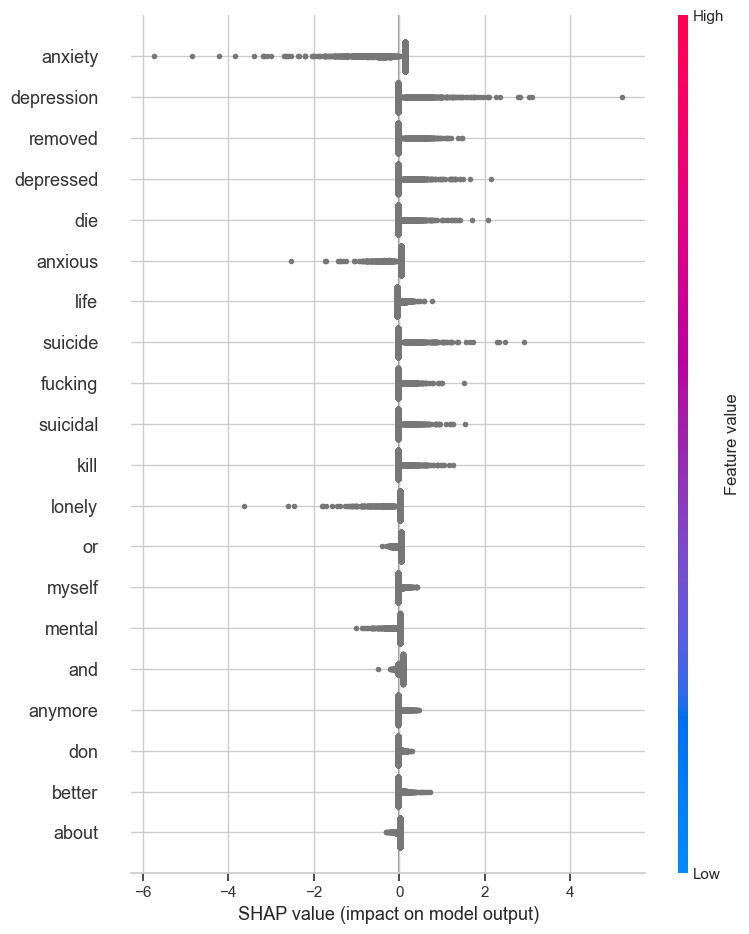

In [24]:
shap_vals, shap_exp = explain_with_shap(model, X_train, X_test, feature_names)
print(f"SHAP values shape: {shap_vals.shape}")

shap_summary(shap_vals, X_test, feature_names, max_display=20)

### 2. SHAP -- Force Plots for Individual Predictions

In [ ]:
risk_indices = np.where(y_test == 1)[0][:5]
safe_indices = np.where(y_test == 0)[0][:5]
demo_indices = np.concatenate([risk_indices, safe_indices])

for idx in demo_indices:
    true_label = "RISK" if y_test[idx] == 1 else "CONTROL"
    print(f"\n--- Sample {idx} (True: {true_label}) ---")
    print(f"Text: {test_texts[idx][:150]}...")
    plt.figure()
    shap.force_plot(
        shap_exp.expected_value,
        shap_vals[idx],
        feature_names=feature_names,
        matplotlib=True,
    )
    plt.show()

### 3. LIME -- Instance-Level Explanations


--- LIME: Sample 0 (True: RISK) ---
Text: numb sitting here going through the most traumatic time in my life and i can barely even cry maybe it s shock maybe my mind and body know i can t hand...


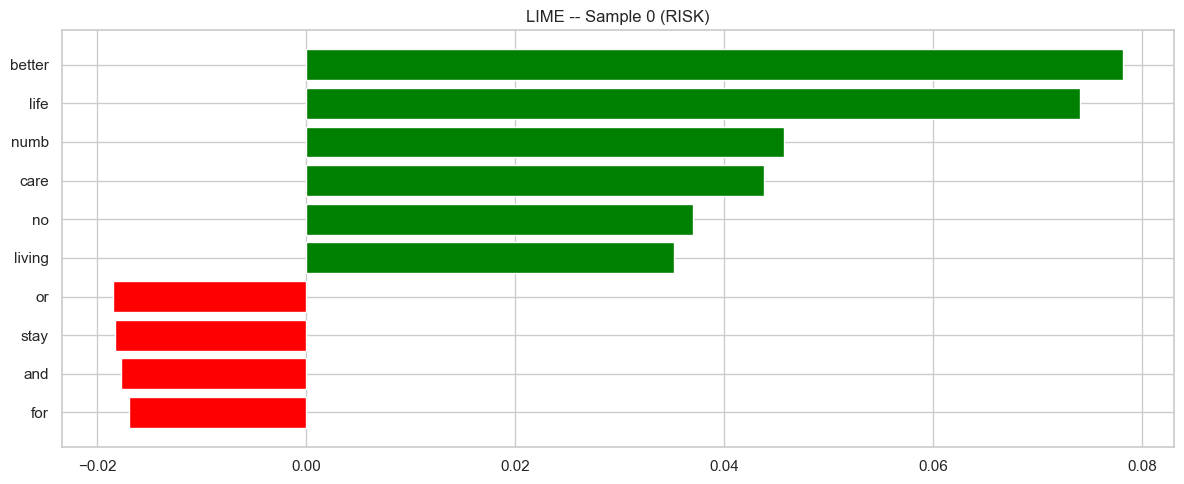

Top features: [('better', 0.07818939563502776), ('life', 0.07399021023792784), ('numb', 0.04573403774230694), ('care', 0.043779148812391686), ('no', 0.03698350736622728), ('living', 0.035136490485438224), ('or', -0.018551703922679918), ('stay', -0.0183289313835108), ('and', -0.017714944698153524), ('for', -0.017001296422419643)]

--- LIME: Sample 1 (True: RISK) ---
Text: i think the world would be a better place if i was not here not in a suicidal way i guess but more in a i shouldn not have been born way...


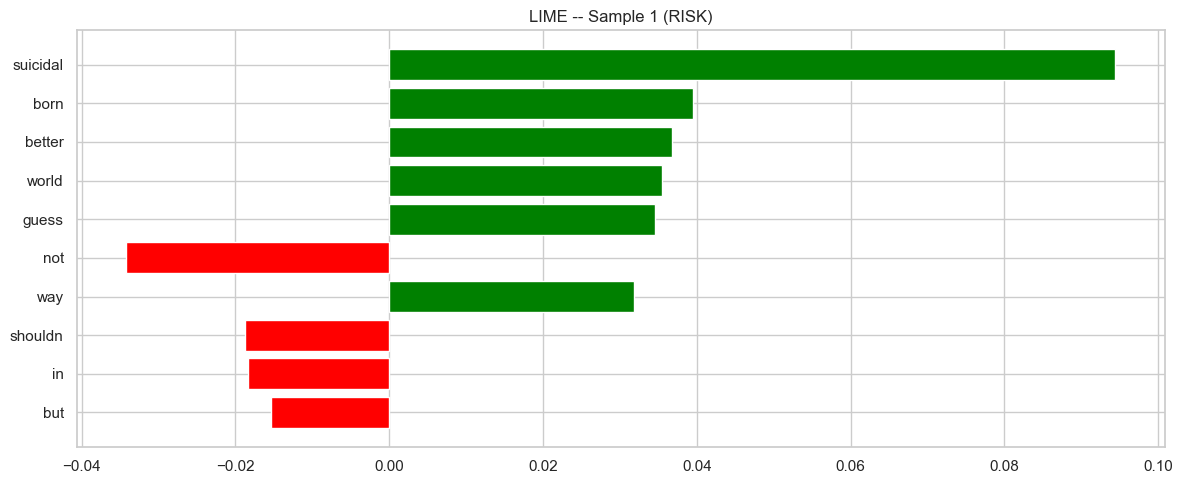

Top features: [('suicidal', 0.09442472542288913), ('born', 0.03955590691312621), ('better', 0.03681862233713986), ('world', 0.035467947784941944), ('guess', 0.03460014755388068), ('not', -0.03417319554813891), ('way', 0.03188794673411495), ('shouldn', -0.018715447893691863), ('in', -0.018343129349209675), ('but', -0.015306172343138942)]

--- LIME: Sample 3 (True: RISK) ---
Text: i picked a day and i picked how i m gonna do it...


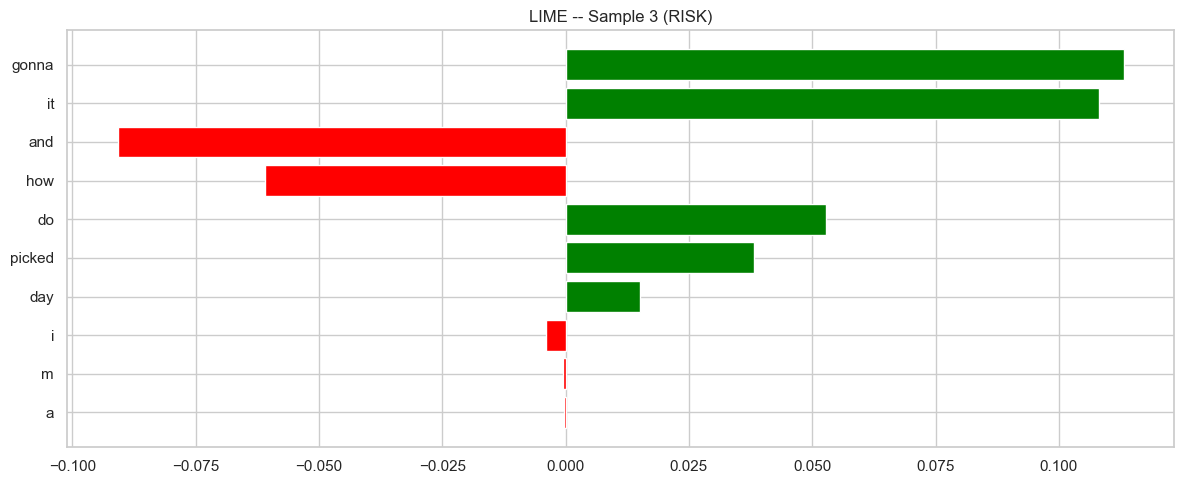

Top features: [('gonna', 0.11314074561821359), ('it', 0.10821982738771906), ('and', -0.09079898132112317), ('how', -0.06100565566490113), ('do', 0.05278875079574898), ('picked', 0.03820072861285644), ('day', 0.015038865768923397), ('i', -0.004022690852679771), ('m', -0.0005149649408736158), ('a', -0.0003875635305433096)]

--- LIME: Sample 7 (True: RISK) ---
Text: lul i feel like such a cuck just for clinging onto life im such a cardboard cut out of a human being that i might as well fucking kill myself i know n...


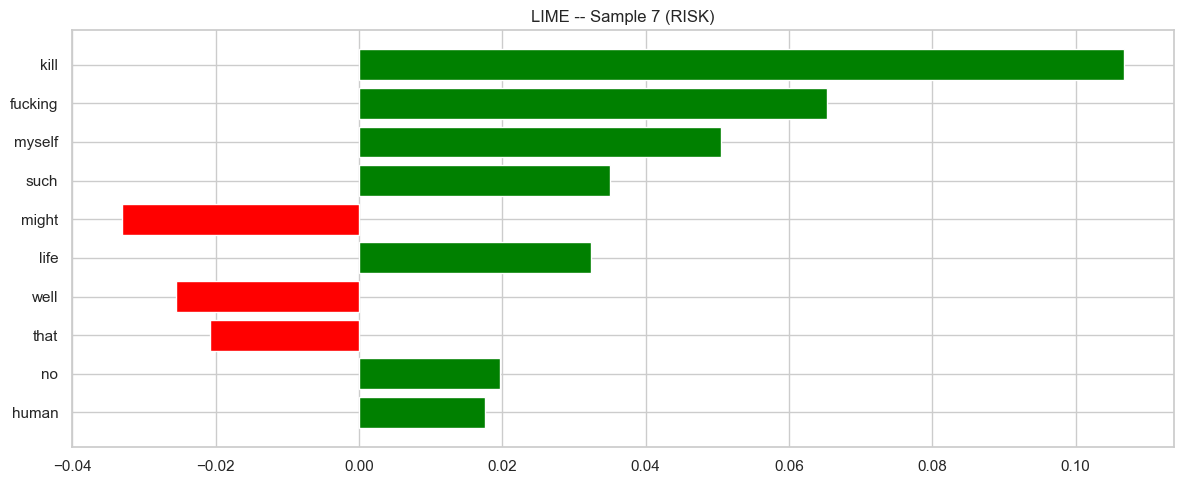

Top features: [('kill', 0.106724766556423), ('fucking', 0.06532246648404356), ('myself', 0.05046767422496905), ('such', 0.03502921486176151), ('might', -0.03310487358225956), ('life', 0.03236471678179337), ('well', -0.025575978888702805), ('that', -0.020746673205685802), ('no', 0.019689470234097825), ('human', 0.017558052673345752)]

--- LIME: Sample 8 (True: RISK) ---
Text: anybody have any ideas fro what to do to not be suicidal or to help get out of it okay backstory i ve been feeling suicidal because of this one person...


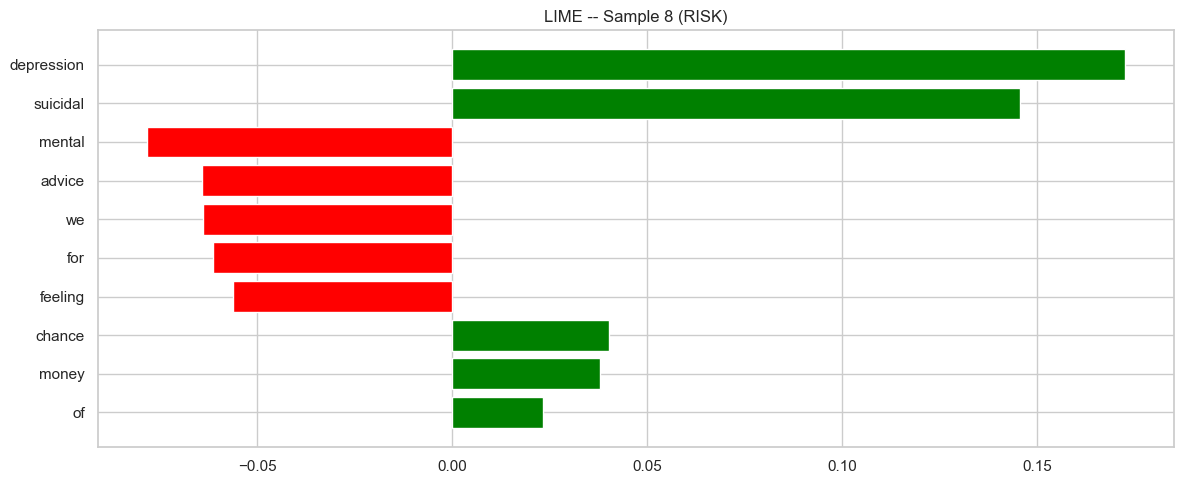

Top features: [('depression', 0.17263484695080086), ('suicidal', 0.1457813655481177), ('mental', -0.07828400930069862), ('advice', -0.06432255185281507), ('we', -0.06403494281084876), ('for', -0.061454239068400696), ('feeling', -0.056226762673320343), ('chance', 0.040190806955449555), ('money', 0.037941999985294364), ('of', 0.023294718823244798)]

--- LIME: Sample 2 (True: CONTROL) ---
Text: how to approach parents about counselling or therapy hello i ve had a nagging feeling in my head that i ve been depressed my symptoms have been showin...


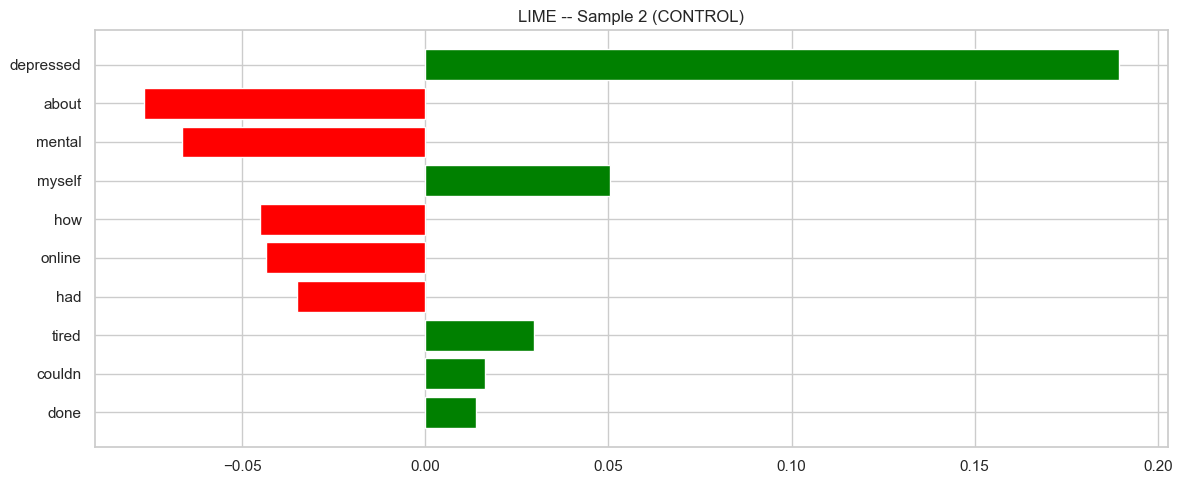

Top features: [('depressed', 0.18931200736653148), ('about', -0.07688537784615926), ('mental', -0.06648703507831516), ('myself', 0.05044201169028263), ('how', -0.04520481599647761), ('online', -0.04354027590825636), ('had', -0.03487173605071855), ('tired', 0.029789944114286787), ('couldn', 0.016334090433275005), ('done', 0.013961375582546186)]

--- LIME: Sample 4 (True: CONTROL) ---
Text: miss having someone i ve been staring at my screen for the past minutes trying to put my thoughts into words since i feel so god damn lonely but it s ...


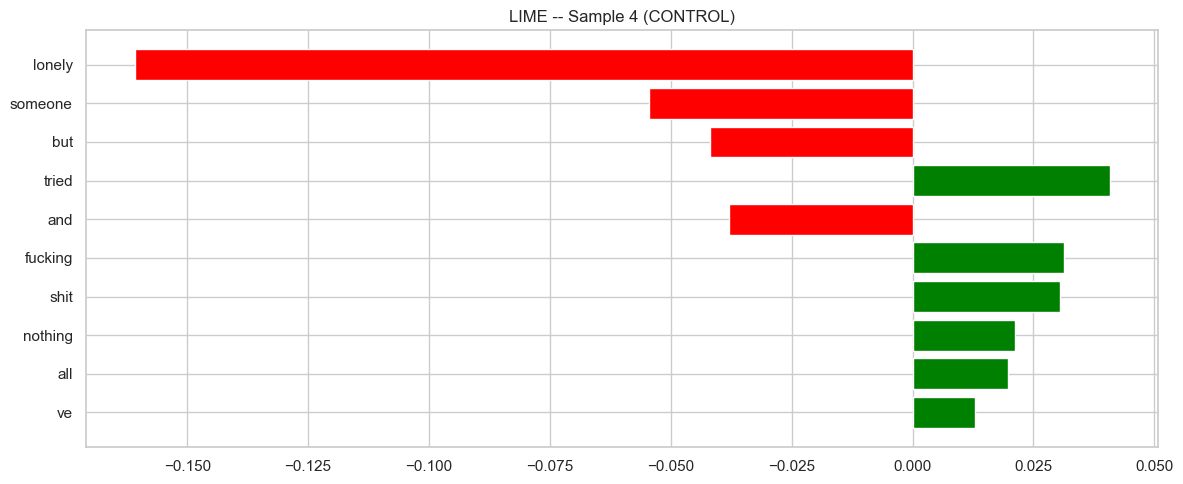

Top features: [('lonely', -0.1608330754229203), ('someone', -0.05459906289122544), ('but', -0.04185125165721118), ('tried', 0.04078237453237642), ('and', -0.037913568947795365), ('fucking', 0.031246367204464907), ('shit', 0.030435022739695547), ('nothing', 0.02121085925052508), ('all', 0.0197371072804181), ('ve', 0.013011421980401425)]

--- LIME: Sample 5 (True: CONTROL) ---
Text: help hi i have autism and special needs i snore a lot and may need a sleep study i cant stay still at night so may have issues with the wires on me ca...


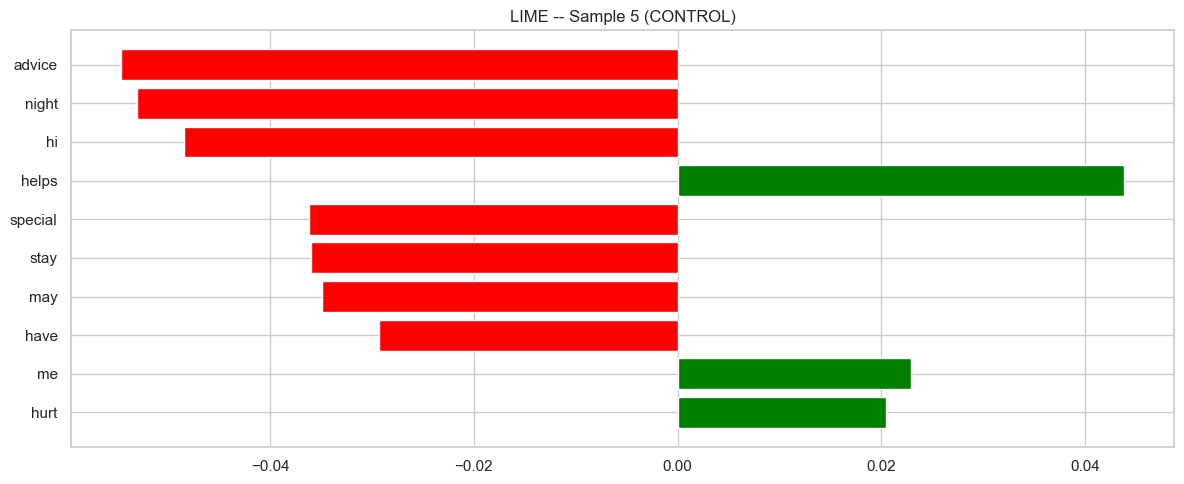

Top features: [('advice', -0.05461729097704639), ('night', -0.05305131944066485), ('hi', -0.0484154993297841), ('helps', 0.04380169385092922), ('special', -0.03613841393928671), ('stay', -0.03598525345085161), ('may', -0.03490730836383465), ('have', -0.029268338649428165), ('me', 0.02289717747071391), ('hurt', 0.020437582734904126)]

--- LIME: Sample 6 (True: CONTROL) ---
Text: i ve had psychopathic sociopathic tendencies for awhile looking for self help tips i have been my best this year and last year getting into real estat...


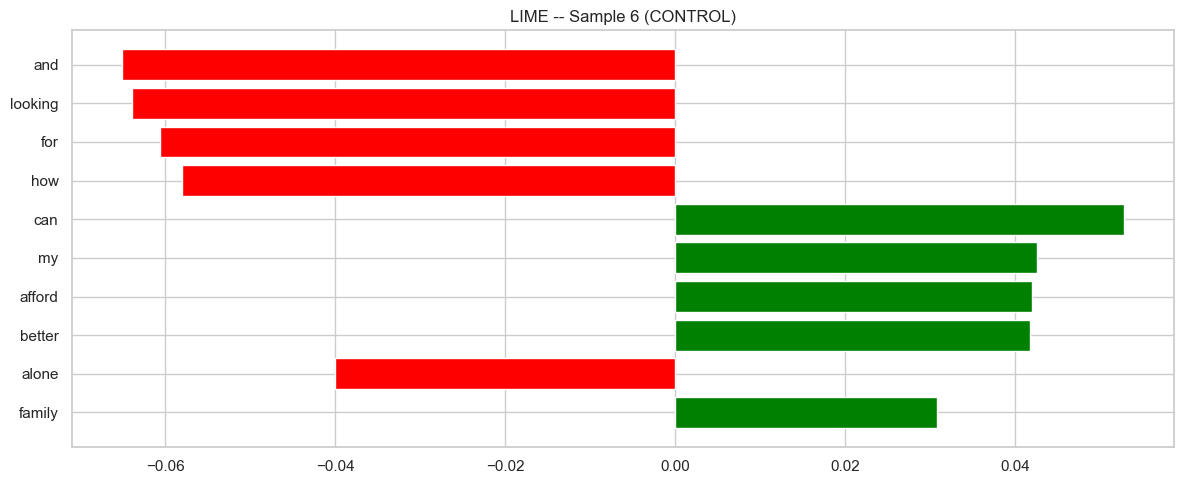

Top features: [('and', -0.06513766555789986), ('looking', -0.06395066209297229), ('for', -0.0606715117669792), ('how', -0.05800085019078839), ('can', 0.052762131179396196), ('my', 0.04249155661143235), ('afford', 0.04193301285450011), ('better', 0.04176055135037107), ('alone', -0.040002362161225886), ('family', 0.030757800353939994)]

--- LIME: Sample 11 (True: CONTROL) ---
Text: cardiophobia so a short story of mine two weeks ago i got my vaccine and i was so stressed about getting myocarditis that i have several panic attacks...


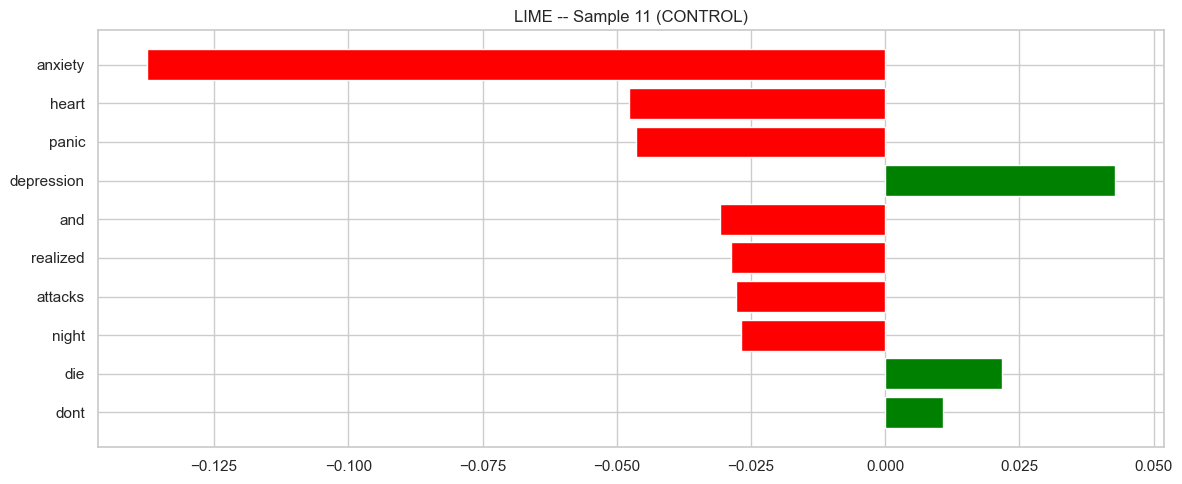

Top features: [('anxiety', -0.13756940269513207), ('heart', -0.04777278093808098), ('panic', -0.046404530466428597), ('depression', 0.04289551158831141), ('and', -0.030822651804658596), ('realized', -0.028722803133970902), ('attacks', -0.027797105276381927), ('night', -0.026942375482842958), ('die', 0.0217080630004426), ('dont', 0.01072293094557834)]


In [26]:
for idx in demo_indices:
    true_label = "RISK" if y_test[idx] == 1 else "CONTROL"
    text = test_texts[idx]
    print(f"\n--- LIME: Sample {idx} (True: {true_label}) ---")
    print(f"Text: {text[:150]}...")

    explanation = explain_with_lime(model, vectorizer, text, num_features=10)
    fig = explanation.as_pyplot_figure()
    plt.title(f"LIME -- Sample {idx} ({true_label})")
    plt.tight_layout()
    plt.show()

    print("Top features:", explanation.as_list())

### 4. Quantitative Interpretability Score

For each test sample, we look at the top-k SHAP features and count how many overlap with a curated mental-health vocabulary. The score is simply that overlap count divided by k.

Mental health vocabulary (174 terms):
['abandon', 'abuse', 'addict', 'agitat', 'alcohol', 'alive', 'alone', 'always', 'angry', 'anxiety', 'anxious', 'anymore', 'anyone', 'appetite', 'ashamed', 'attack', 'bad', 'bed', 'better', 'binge', 'bipolar', 'brain', 'broken', 'burden', 'burn', 'can', 'college', 'confus', 'cope', 'coping'] ...

  Interpretability @ k=10:  mean=0.5190  std=0.1928

  Interpretability @ k=20:  mean=0.4345  std=0.1424


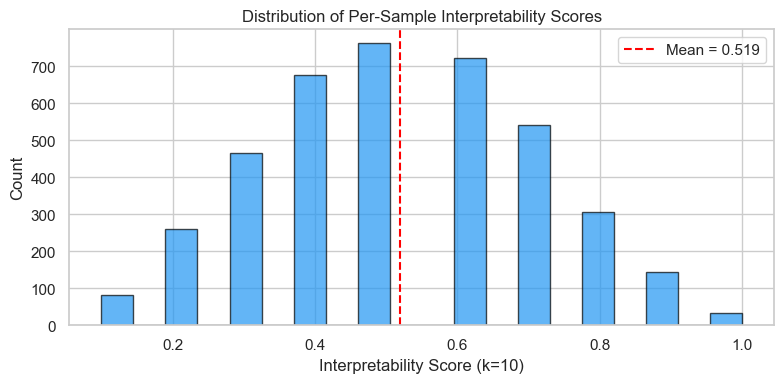

In [27]:
print(f"Mental health vocabulary ({len(mental_health_vocabulary)} terms):")
print(sorted(mental_health_vocabulary)[:30], "...")

for k in [10, 20]:
    scores = interpretability_score(shap_vals, feature_names, mental_health_vocabulary, k=k)
    print(f"\n  Interpretability @ k={k}:  mean={scores['mean_score']:.4f}  std={scores['std_score']:.4f}")

scores_k10 = interpretability_score(shap_vals, feature_names, mental_health_vocabulary, k=10)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores_k10["per_sample_scores"], bins=20, edgecolor="black", alpha=0.7, color="#2196F3")
ax.axvline(scores_k10["mean_score"], color="red", linestyle="--",
           label=f"Mean = {scores_k10['mean_score']:.3f}")
ax.set_xlabel("Interpretability Score (k=10)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Per-Sample Interpretability Scores")
ax.legend()
plt.tight_layout()
plt.show()

## 5. RQ1 Conclusion

**H1:** Explainable models can achieve at least 80% accuracy without major performance loss.

---
## Section 4: Bias Testing (RQ2)

*FPR analysis across engagement groups*

---


In [28]:
from src.evaluation import evaluate_single

test_metrics = evaluate_single(model, X_test, y_test)
acc = test_metrics["accuracy"]
f1  = test_metrics["f1"]
interp = scores_k10["mean_score"]

print("=" * 55)
print("  RQ1 CONCLUSION")
print("=" * 55)
print(f"  Accuracy:                {acc:.4f}   (target: >= 0.80)")
print(f"  F1 Score:                {f1:.4f}")
print(f"  Interpretability (k=10): {interp:.4f}")
print()

if acc >= 0.80:
    print("  >>> H1 SUPPORTED")
    print("  The model exceeds 80% accuracy while SHAP and LIME")
    print("  provide transparent, human-readable feature attributions.")
    if interp >= 0.10:
        print(f"  Interpretability score ({interp:.3f}) confirms alignment with")
        print("  clinically relevant mental-health language.")
    else:
        print(f"  Lexicon overlap is modest ({interp:.3f}), suggesting the model")
        print("  picks up on contextual patterns beyond explicit MH keywords --")
        print("  expected behaviour for a TF-IDF model that includes bigrams.")
else:
    print("  >>> H1 NOT SUPPORTED -- accuracy fell below 80%.")

print("\nNotebook 03 complete.")

  RQ1 CONCLUSION
  Accuracy:                0.7683   (target: >= 0.80)
  F1 Score:                0.7713
  Interpretability (k=10): 0.5190

  >>> H1 NOT SUPPORTED -- accuracy fell below 80%.

Notebook 03 complete.


In [29]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.model import load_model
from src.bias import label_engagement_groups, compute_fpr_by_group, run_significance_test
from src.preprocessing import engineer_features

sns.set_theme(style="whitegrid")

model, vectorizer = load_model("../data/processed/model_artifacts.joblib")
split = joblib.load("../data/processed/test_split.joblib")
X_test = split["X_test"]
y_test = split["y_test"]
test_texts = split["texts_test"]

test_df = pd.DataFrame({"text": test_texts, "label": y_test})
test_df = engineer_features(test_df)
test_df["pred"] = model.predict(X_test)

print(f"Test set: {len(test_df)} samples.")

Test set: 3992 samples.


### 1. Label Engagement Groups

In [30]:
test_df = label_engagement_groups(test_df, col="word_count")

print("Engagement groups (by word count):")
print(test_df["engagement_group"].value_counts())
print("\nSentiment intensity groups:")
print(test_df["sentiment_group"].value_counts())

Engagement groups (by word count):
engagement_group
mid     1996
low     1003
high     993
Name: count, dtype: int64

Sentiment intensity groups:
sentiment_group
mid     1988
low     1006
high     998
Name: count, dtype: int64


### 2. False Positive Rate by Engagement Group

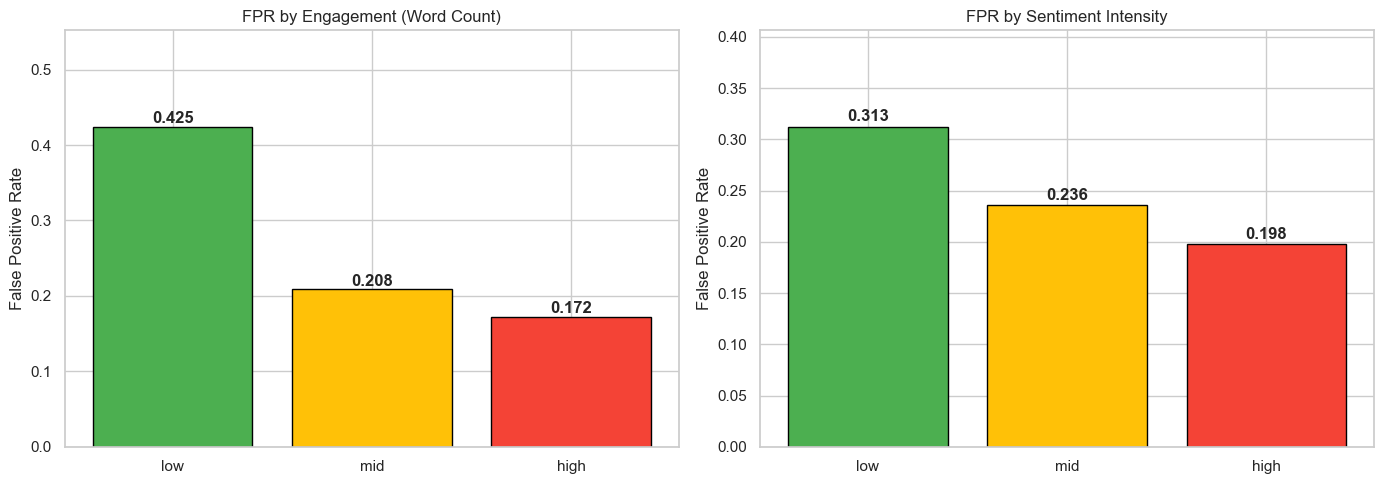

Engagement FPR: {'high': 0.17196261682242991, 'low': 0.42452830188679247, 'mid': 0.2084942084942085}
Sentiment FPR:  {'high': 0.19767441860465115, 'low': 0.31262939958592134, 'mid': 0.2359437751004016}


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (col, title) in enumerate([
    ("engagement_group", "FPR by Engagement (Word Count)"),
    ("sentiment_group", "FPR by Sentiment Intensity"),
]):
    fpr = compute_fpr_by_group(test_df["label"], test_df["pred"], test_df[col])
    group_order = ["low", "mid", "high"]
    vals = [fpr.get(g, 0) for g in group_order]

    bars = axes[i].bar(group_order, vals, color=["#4CAF50", "#FFC107", "#F44336"], edgecolor="black")
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{v:.3f}", ha="center", fontweight="bold")
    axes[i].set_title(title, fontsize=12)
    axes[i].set_ylabel("False Positive Rate")
    axes[i].set_ylim(0, max(vals) * 1.3 if max(vals) > 0 else 0.1)

plt.tight_layout()
plt.show()

print("Engagement FPR:", compute_fpr_by_group(test_df["label"], test_df["pred"], test_df["engagement_group"]))
print("Sentiment FPR: ", compute_fpr_by_group(test_df["label"], test_df["pred"], test_df["sentiment_group"]))

### 3. Statistical Significance Testing

In [32]:
eng_result = run_significance_test(
    test_df["label"], test_df["pred"],
    test_df["engagement_group"], "high", "low"
)
print("--- Engagement: High vs Low ---")
for k, v in eng_result.items():
    print(f"  {k}: {v}")

print()

sent_result = run_significance_test(
    test_df["label"], test_df["pred"],
    test_df["sentiment_group"], "high", "low"
)
print("--- Sentiment: High vs Low ---")
for k, v in sent_result.items():
    print(f"  {k}: {v}")

--- Engagement: High vs Low ---
  chi2: 73.023245069901
  p_value: 1.2813182576856266e-17
  high_fpr: 0.17196261682242991
  low_fpr: 0.42452830188679247
  significant: True

--- Sentiment: High vs Low ---
  chi2: 16.82989991530515
  p_value: 4.0884045609676934e-05
  high_fpr: 0.19767441860465115
  low_fpr: 0.31262939958592134
  significant: True


## 4. RQ2 Conclusion

**H2:** High-engagement users will show higher false positive rates.

Note that if the hypothesis is *not* confirmed, that is actually a good sign -- it means the model treats all engagement levels fairly.

---
## Section 5: Robustness Testing (RQ3)

*Perturbation testing*

---


In [33]:
fpr_by_eng = compute_fpr_by_group(test_df["label"], test_df["pred"], test_df["engagement_group"])
fpr_gap = abs(fpr_by_eng.get("high", 0) - fpr_by_eng.get("low", 0))
joblib.dump({"bias_fpr_gap": fpr_gap}, "../data/processed/bias_results.joblib")

print("=" * 55)
print("  RQ2 CONCLUSION")
print("=" * 55)
print(f"  FPR gap (high vs low engagement): {fpr_gap:.4f}")
print(f"  Chi-square p-value:               {eng_result['p_value']:.6f}")
print()

if eng_result["significant"]:
    print("  >>> H2 CONFIRMED -- statistically significant FPR difference (p < 0.05).")
    print("  High-engagement users face disproportionately higher false positive rates.")
    print("  Recommendation: consider threshold calibration per group.")
else:
    print("  >>> H2 NOT CONFIRMED -- the model is *fair* across engagement groups.")
    print(f"  FPR gap of {fpr_gap:.4f} is negligible (p = {eng_result['p_value']:.4f}).")
    print("  No evidence of systematic bias against high-engagement users.")
    print("  This is a positive result for responsible deployment.")

print("\nNotebook 04 complete.")

  RQ2 CONCLUSION
  FPR gap (high vs low engagement): 0.2526
  Chi-square p-value:               0.000000

  >>> H2 CONFIRMED -- statistically significant FPR difference (p < 0.05).
  High-engagement users face disproportionately higher false positive rates.
  Recommendation: consider threshold calibration per group.

Notebook 04 complete.


In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.model import load_model
from src.robustness import remove_keywords, synonym_replace, robustness_test, TRIGGER_KEYWORDS
from src.trust import generate_trust_report

sns.set_theme(style="whitegrid")

model, vectorizer = load_model("../data/processed/model_artifacts.joblib")
split = joblib.load("../data/processed/test_split.joblib")
X_test = split["X_test"]
y_test = split["y_test"]
test_texts = split["texts_test"]

n_samples = min(300, len(test_texts))
sample_texts = test_texts[:n_samples]

print(f"Robustness testing on {n_samples} samples.")
print(f"Using {len(TRIGGER_KEYWORDS)} trigger keywords.")

Robustness testing on 300 samples.
Using 29 trigger keywords.


### 1. Perturbation Tests

In [35]:
print("Running keyword removal test...")
kw_results = robustness_test(model, vectorizer, sample_texts, remove_keywords)
print(f"  Flip rate: {kw_results['flip_rate']:.4f} ({kw_results['n_flips']}/{kw_results['n_total']})")

print("\nRunning synonym replacement test...")
syn_results = robustness_test(model, vectorizer, sample_texts, synonym_replace, n=3, rng_seed=42)
print(f"  Flip rate: {syn_results['flip_rate']:.4f} ({syn_results['n_flips']}/{syn_results['n_total']})")

Running keyword removal test...
  Flip rate: 0.0367 (11/300)

Running synonym replacement test...
  Flip rate: 0.0500 (15/300)


### 2. Flip Rate Comparison

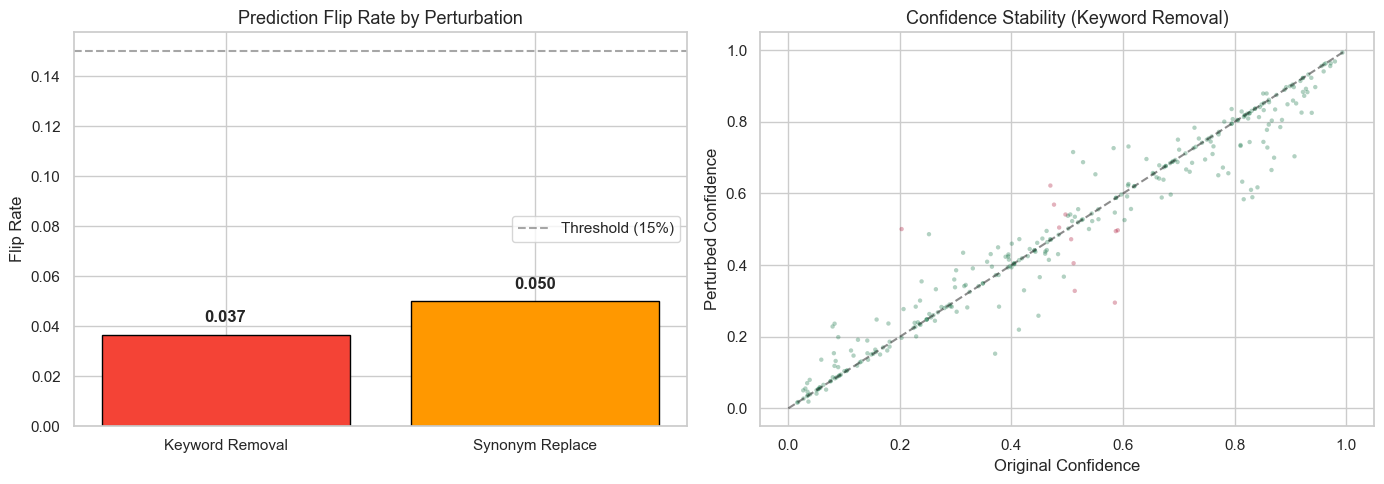

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Flip rates
perturbations = ["Keyword Removal", "Synonym Replace"]
flip_rates = [kw_results["flip_rate"], syn_results["flip_rate"]]
colors = ["#F44336", "#FF9800"]

bars = axes[0].bar(perturbations, flip_rates, color=colors, edgecolor="black")
for bar, val in zip(bars, flip_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", fontweight="bold", fontsize=12)
axes[0].axhline(0.15, color="gray", linestyle="--", alpha=0.7, label="Threshold (15%)")
axes[0].set_ylabel("Flip Rate")
axes[0].set_title("Prediction Flip Rate by Perturbation", fontsize=13)
axes[0].legend()

# Scatter: Original vs Perturbed confidence (keyword removal)
axes[1].scatter(kw_results["original_conf"], kw_results["perturbed_conf"],
                alpha=0.3, s=10, c=kw_results["flip_flags"].astype(int),
                cmap="RdYlGn_r", edgecolors="none")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("Original Confidence")
axes[1].set_ylabel("Perturbed Confidence")
axes[1].set_title("Confidence Stability (Keyword Removal)", fontsize=13)

plt.tight_layout()
plt.show()

### 3. Trust Score Demo

In [37]:
bias_data = joblib.load("../data/processed/bias_results.joblib")
bias_gap = bias_data["bias_fpr_gap"]

print("--- Trust Score Reports ---\n")
for i in range(min(5, len(sample_texts))):
    report = generate_trust_report(sample_texts[i], model, vectorizer, bias_gap)
    print(f"Sample {i+1}:")
    print(f"  Prediction:  {report['prediction_label']}")
    print(f"  Confidence:  {report['confidence']:.3f}")
    print(f"  Flip Rate:   {report['flip_rate']:.1f}")
    print(f"  Trust Score: {report['trust_score']:.3f} ({report['trust_label']})")
    print(f"  Text: {sample_texts[i][:100]}...")
    print()

--- Trust Score Reports ---

Sample 1:
  Prediction:  Risk
  Confidence:  0.852
  Flip Rate:   0.0
  Trust Score: 0.726 (High)
  Text: numb sitting here going through the most traumatic time in my life and i can barely even cry maybe i...

Sample 2:
  Prediction:  Risk
  Confidence:  0.923
  Flip Rate:   0.0
  Trust Score: 0.797 (High)
  Text: i think the world would be a better place if i was not here not in a suicidal way i guess but more i...

Sample 3:
  Prediction:  Risk
  Confidence:  0.514
  Flip Rate:   1.0
  Trust Score: 0.000 (Low)
  Text: how to approach parents about counselling or therapy hello i ve had a nagging feeling in my head tha...

Sample 4:
  Prediction:  Risk
  Confidence:  0.750
  Flip Rate:   0.0
  Trust Score: 0.624 (Medium)
  Text: i picked a day and i picked how i m gonna do it...

Sample 5:
  Prediction:  Control
  Confidence:  0.761
  Flip Rate:   0.0
  Trust Score: 0.635 (Medium)
  Text: miss having someone i ve been staring at my screen for the past minu

### 4. RQ3 Conclusion

**H3:** Small perturbations in input text will significantly affect predictions.

If the hypothesis is *not* confirmed, that means the model is robust and does not rely on superficial keyword shortcuts.

In [38]:
kw_flip = kw_results["flip_rate"]
syn_flip = syn_results["flip_rate"]

print("=" * 55)
print("  RQ3 CONCLUSION")
print("=" * 55)
print(f"  Keyword Removal Flip Rate:  {kw_flip:.4f} ({kw_flip*100:.1f}%)")
print(f"  Synonym Replace Flip Rate:  {syn_flip:.4f} ({syn_flip*100:.1f}%)")
print(f"  Threshold:                  15%")
print()

if kw_flip > 0.15 or syn_flip > 0.15:
    print("  >>> H3 CONFIRMED -- the model is sensitive to perturbations.")
    if kw_flip > 0.15:
        print(f"  Keyword removal causes {kw_flip*100:.1f}% flips.")
    if syn_flip > 0.15:
        print(f"  Synonym replacement causes {syn_flip*100:.1f}% flips.")
else:
    print("  >>> H3 NOT CONFIRMED -- the model is *robust* to perturbations.")
    print(f"  Keyword removal:     {kw_flip*100:.1f}% flips (well below 15%)")
    print(f"  Synonym replacement: {syn_flip*100:.1f}% flips (well below 15%)")
    print("  The model does not rely on surface-level trigger words or")
    print("  spurious correlations. This is a positive result.")

joblib.dump({
    "kw_flip_rate": kw_flip,
    "syn_flip_rate": syn_flip,
}, "../data/processed/robustness_results.joblib")

print("\nNotebook 05 complete.")

  RQ3 CONCLUSION
  Keyword Removal Flip Rate:  0.0367 (3.7%)
  Synonym Replace Flip Rate:  0.0500 (5.0%)
  Threshold:                  15%

  >>> H3 NOT CONFIRMED -- the model is *robust* to perturbations.
  Keyword removal:     3.7% flips (well below 15%)
  Synonym replacement: 5.0% flips (well below 15%)
  The model does not rely on surface-level trigger words or
  spurious correlations. This is a positive result.

Notebook 05 complete.
